# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Import the libraries that we will need
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Load the COMPAS dataset from GitHub into pandas dataframe
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

# Return the number of rows in the raw dataset.
raw_data.shape[0]

7214

In [6]:
# Display the first 10 rows
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [7]:
import pandas as pd

numeric_vars  = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = (raw_data[["age", "c_charge_degree", "race", "age_cat",
                "score_text", "sex", "priors_count",
                "days_b_screening_arrest", "decile_score", "is_recid",
                "two_year_recid", "c_jail_in", "c_jail_out"]]
    # ── Filtering ────────────────────────────────────────────────────
    .query("-30 <= days_b_screening_arrest <= 30")
    .query("is_recid != -1")
    .query("c_charge_degree != 'O'")
    .query("score_text != 'N/A'")
    .copy()
)

# ── Type conversions ─────────────────────────────────────────────
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

cat_cols = [c for c in df.columns if c not in numeric_vars + datetime_vars]
for col in cat_cols:
    df[col] = df[col].astype("category")

# ── Derived factors with reference levels ─────────────────────────
df["crime_factor"] = df["c_charge_degree"].astype("category")

df["age_factor"] = pd.Categorical(df["age_cat"],
                      categories=["25 - 45"] + [c for c in df["age_cat"].unique()
                                                 if c != "25 - 45"])

df["race_factor"] = pd.Categorical(df["race"],
                       categories=["Caucasian"] + [c for c in df["race"].unique()
                                                    if c != "Caucasian"])

df["gender_factor"] = pd.Categorical(df["sex"].map({0: "Female", 1: "Male"}),
                          categories=["Male", "Female"])

df["score_factor"] = pd.Categorical(
                        df["score_text"].apply(lambda x: "LowScore" if x == "Low"
                                                          else "HighScore"),
                        categories=["LowScore", "HighScore"])

print(len(df))

6172


In [8]:
# Preview the cleaned and transformed dataset.
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,NaN,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,NaN,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,NaN,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,NaN,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,NaN,HighScore


In [9]:
# Show column types, non-null counts, and memory usage to verify preprocessing worked.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [10]:
# Calculate length of stay in days by subtracting jail-in from jail-out datetime columns
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days

# Compute Pearson correlation between length of stay and COMPAS decile score
df["length_of_stay"].corr(df["decile_score"])

np.float64(0.20747808478031807)

After filtering we have the following demographic breakdown:

In [11]:
# Summarize the distribution of age categories with counts by level.
age_order = ["25 - 45", "Greater than 45", "Less than 25"]
df["age_cat"].value_counts().reindex(age_order)


,count
age_cat,
25 - 45,3532
Greater than 45,1293
Less than 25,1347


In [12]:
# Summarize the distribution of race categories with counts by level.
race_order = ["African-American", "Asian", "Caucasian", "Hispanic", "Native American", "Other"]
df["race"].value_counts().reindex(race_order)


,count
race,
African-American,3175
Asian,31
Caucasian,2103
Hispanic,509
Native American,11
Other,343


In [13]:
# Print the percentage of defendants in each race group using fixed counts.
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))


Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [14]:
# Summarize how often each COMPAS risk label appears.
score_order = ["High", "Low", "Medium"]
df["score_text"].value_counts().reindex(score_order)


,count
score_text,
High,1144
Low,3421
Medium,1607


In [15]:
# Create a table showing the count of defendants by sex and race.
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [ ]:
# Summarize the distribution of sex in the dataset.
sex_order = ["Female", "Male"]
df["sex"].value_counts().reindex(sex_order)


,count
sex,
Female,1175
Male,4997


In [16]:
# Print the percentage of men and women in the dataset using fixed counts.
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))


Men: 80.96%
Women: 19.04%


In [ ]:
# Count how many defendants were rearrested within two years.
df.query("two_year_recid == 1").shape[0]

2809

In [ ]:
# Compute the overall two-year recidivism rate as a percentage.
df.query("two_year_recid == 1").shape[0] / df.shape[0] * 100

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

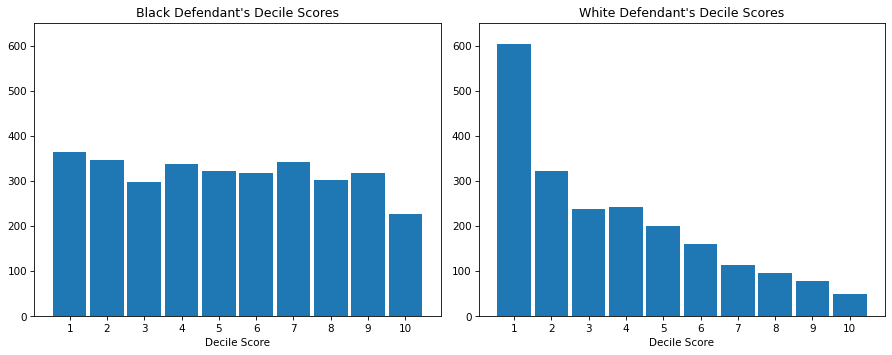

In [28]:
# For African-American and Caucasian defendants
fig, axes = plt.subplots(1, 2, figsize=(12, 4.84), dpi=75)

black_scores = df.loc[df["race"].astype(str) == "African-American", "decile_score"]
white_scores = df.loc[df["race"].astype(str) == "Caucasian", "decile_score"]

black_counts = black_scores.value_counts().sort_index()
white_counts = white_scores.value_counts().sort_index()

axes[0].bar(black_counts.index, black_counts.values, width=0.9)
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xticks(range(1, 11))

axes[1].bar(white_counts.index, white_counts.values, width=0.9)
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [24]:
# Build a frequency table of decile scores by race.
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [30]:
# ── Rebuild gender_factor from sex column (contains "Male"/"Female" strings) ─
df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"])

# ── Remove unused categories from all other categorical columns ───────────────
for col in ["age_factor", "race_factor", "crime_factor"]:
    df[col] = df[col].cat.remove_unused_categories()

# ── Create binary outcome column ─────────────────────────────────────────────
df["score_high"] = (df["score_text"] != "Low").astype(int)

# ── Fit logistic regression ───────────────────────────────────────────────────
model_glm = smf.glm(
    formula="score_high ~ C(gender_factor, Treatment(reference='Male')) + "
            "C(age_factor, Treatment(reference='25 - 45')) + "
            "C(race_factor, Treatment(reference='Caucasian')) + "
            "priors_count + "
            "C(crime_factor) + "
            "two_year_recid",
    data=df,
    family=sm.families.Binomial()
).fit()

print(model_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             score_high   No. Observations:                 6172
Model:                            GLM   Df Residuals:                     6160
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3084.2
Date:                Fri, 27 Mar 2026   Deviance:                       6168.4
Time:                        20:06:45   Pearson chi2:                 6.07e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3128
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [39]:
# Convert the intercept from log-odds to a baseline probability.
# This represents the predicted probability for the reference group
# (Male, 25-45, Caucasian, no priors, misdemeanor, no recidivism).
control = np.exp(model_glm.params["Intercept"]) / (1 + np.exp(model_glm.params["Intercept"]))

# Pull the log-odds coefficient for African-American defendants relative to Caucasian.
# Then convert to an odds ratio and compute the predicted probability,
# holding all other features at their reference levels.
# This tells us how much more likely a Black defendant is to receive a high score
# compared to an otherwise identical Caucasian defendant.
np.exp(model_glm.params["C(race_factor, Treatment(reference='Caucasian'))[T.African-American]"]) / (
    1 - control + (
        control * np.exp(model_glm.params["C(race_factor, Treatment(reference='Caucasian'))[T.African-American]"])
    )
)

np.float64(1.452837413382347)

Women are 19.4% more likely than men to get a higher score.

In [40]:
# Repeat the probability-adjusted odds calculation for the Female coefficient.
np.exp(model_glm.params["C(gender_factor, Treatment(reference='Male'))[T.Female]"]) / (
    1 - control + (
        control * np.exp(model_glm.params["C(gender_factor, Treatment(reference='Male'))[T.Female]"])
    )
)

np.float64(1.1947946538834504)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [41]:
# Repeat the probability-adjusted odds calculation
np.exp(model_glm.params["C(age_factor, Treatment(reference='25 - 45'))[T.Less than 25]"]) / (
    1 - control + (
        control * np.exp(model_glm.params["C(age_factor, Treatment(reference='25 - 45'))[T.Less than 25]"])
    )
)

np.float64(2.4961195307539548)

In [42]:
# Use the fitted model to generate predicted probabilities for each row before converting probabilities into class predictions using a 0.5 threshold
df = df.assign(
    pred_prob=model_glm.predict(df),
    pred_class=pd.Categorical(
        np.where(model_glm.predict(df) >= 0.5, "Recid", "No Recid"),
        categories=["No Recid", "Recid"]
    )
)

In [43]:
# Print the overall confusion matrix comparing predicted classes to actual outcomes.
print("\n── Overall Confusion Matrix ──────────────────────────────────────────")

overall_cm = pd.crosstab(
    index=df["pred_class"],
    columns=df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)
print(overall_cm)

# Extract confusion-matrix components:
# TP = true positives, TN = true negatives, FP = false positives, FN = false negatives.
TP  = overall_cm.loc["Recid", 1]
TN  = overall_cm.loc["No Recid", 0]
FP  = overall_cm.loc["Recid", 0]
FN  = overall_cm.loc["No Recid", 1]
n   = overall_cm.to_numpy().sum()

# Calculate standard classification metrics for the full dataset.
print("\nAccuracy  : %.3f" % ((TP + TN) / n))
print("Precision : %.3f" % (TP / (TP + FP)))
print("Recall    : %.3f" % (TP / (TP + FN)))
print("FPR       : %.3f" % (FP / (FP + TN)))
print("FNR       : %.3f" % (FN / (FN + TP)))



── Overall Confusion Matrix ──────────────────────────────────────────
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [45]:
# Compute confusion-matrix counts and performance metrics separately for each race group to evaluate whether model errors differ across demographics.
print("\n\nConfusion Matrix by Race")

race_metrics = (
    df.assign(
        actual=df["two_year_recid"].astype(int),
        pred=(df["pred_class"].astype(str) == "Recid").astype(int)
    )
    .groupby("race", observed=False)
    .apply(lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    }))
    .reset_index()
)

# Derive accuracy, precision, recall, false positive rate, and false negative rate by race.
race_metrics["Accuracy"]  = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"]    = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"]       = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"]       = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

# Match the R notebook by ordering races from largest to smallest group.
race_metrics = race_metrics.sort_values("n", ascending=False).reset_index(drop=True)
race_metrics




Confusion Matrix by Race


,race,n,TP,TN,FP,FN,Accuracy,Precision,Recall,FPR,FNR
0,African-American,3175,1373,959,555,288,0.734,0.712,0.827,0.367,0.173
1,Caucasian,2103,381,1148,133,441,0.727,0.741,0.464,0.104,0.536
2,Hispanic,509,81,306,14,108,0.760,0.853,0.429,0.044,0.571
3,Other,343,22,216,3,102,0.694,0.880,0.177,0.014,0.823
4,Asian,31,2,22,1,6,0.774,0.667,0.250,0.043,0.750
5,Native American,11,5,2,4,0,0.636,0.556,1.000,0.667,0.000
